In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import warnings
import os
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

df = pd.read_csv(r"C:\Projects\ipo-subscription-prediction\data\processed\ipo_enriched.csv")
le = LabelEncoder()
df["sector_encoded"] = le.fit_transform(df["sector"])

feature_cols = [
    "issue_price", "issue_size_cr", "issue_size_log",
    "nifty_avg", "nifty_volatility", "nifty_yearly_return",
    "sector_encoded"
]

X = df[feature_cols]
y = df["subscription_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data loaded successfully!")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded successfully!
Train: (71, 7) | Test: (18, 7)


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "verbosity": 0
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(f"Best CV accuracy: {study.best_value:.3f}")
print(f"Best parameters: {study.best_params}")

Best CV accuracy: 0.518
Best parameters: {'n_estimators': 210, 'max_depth': 5, 'learning_rate': 0.010098660116554928, 'subsample': 0.9922090849408666, 'colsample_bytree': 0.642873043509403, 'min_child_weight': 10}


In [3]:
best_params = study.best_params
best_params["random_state"] = 42
best_params["verbosity"] = 0

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("=== Tuned XGBoost — Test Set Evaluation ===\n")
print(classification_report(y_test, y_pred,
      target_names=["Under-subscribed", "Low (1-10x)", "Medium (10-50x)", "High (50x+)"]))

os.makedirs(r"C:\Projects\ipo-subscription-prediction\models", exist_ok=True)
joblib.dump(final_model, r"C:\Projects\ipo-subscription-prediction\models\xgboost_final.pkl")
joblib.dump(le, r"C:\Projects\ipo-subscription-prediction\models\label_encoder.pkl")
print("Model saved successfully!")

=== Tuned XGBoost — Test Set Evaluation ===

                  precision    recall  f1-score   support

Under-subscribed       0.00      0.00      0.00         1
     Low (1-10x)       0.50      0.60      0.55         5
 Medium (10-50x)       0.00      0.00      0.00         4
     High (50x+)       0.50      0.62      0.56         8

        accuracy                           0.44        18
       macro avg       0.25      0.31      0.28        18
    weighted avg       0.36      0.44      0.40        18

Model saved successfully!


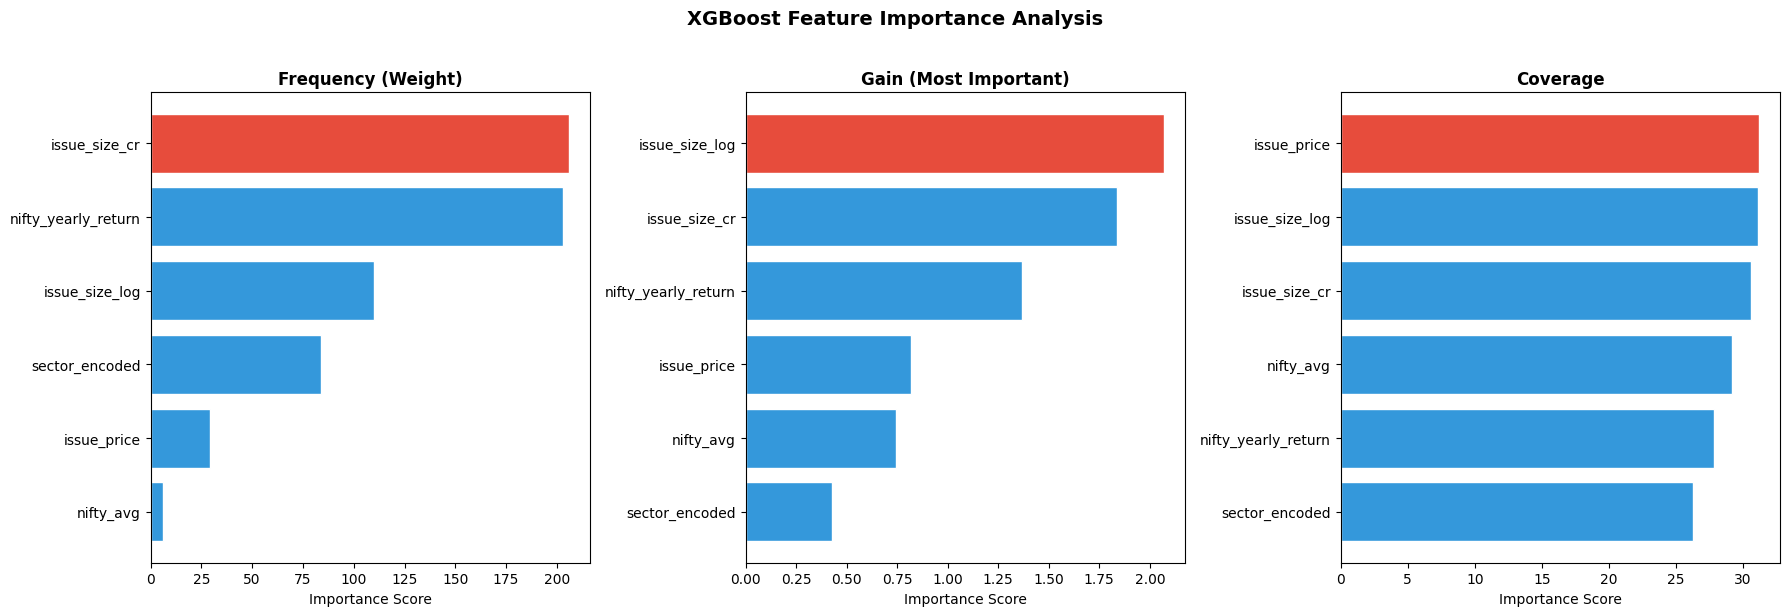

Top features by Gain (most meaningful metric):
               feature      gain
2       issue_size_log  2.070549
1        issue_size_cr  1.836216
4  nifty_yearly_return  1.368059
0          issue_price  0.818324
3            nifty_avg  0.742969
5       sector_encoded  0.429184


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# XGBoost built-in feature importance — 3 types
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

importance_types = ["weight", "gain", "cover"]
titles = ["Frequency (Weight)", "Gain (Most Important)", "Coverage"]

for ax, imp_type, title in zip(axes, importance_types, titles):
    importance = final_model.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame({
        "feature": list(importance.keys()),
        "importance": list(importance.values())
    }).sort_values("importance", ascending=True)
    
    colors = ["#3498db"] * len(imp_df)
    colors[-1] = "#e74c3c"  # top feature red
    
    ax.barh(imp_df["feature"], imp_df["importance"], color=colors, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.suptitle("XGBoost Feature Importance Analysis", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Projects\ipo-subscription-prediction\reports\feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top features
print("Top features by Gain (most meaningful metric):")
gain_importance = final_model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({
    "feature": list(gain_importance.keys()),
    "gain": list(gain_importance.values())
}).sort_values("gain", ascending=False)
print(gain_df)